# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Trần Hải My"  # TODO: Họ và tên
STUDENT_ID = "2554023"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Hải My (2554023)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /Users/tranhaimy/Documents/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = ~(correct_mask & high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports
2. Ký hiệu Missing Value là dấu ?
3. symboling thể hiện mức đánh giá rủi ro bảo hiểm



## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

- Không nên fill tất cả numeric columns bằng cùng 1 giá trị vì mỗi feature có một thang đo và phân phối khác nhau nên việc fill như vậy sẽ làm sai lệch hoàn toàn thống kê của dữ liệu.
- Với price, lựa chọn drop sẽ phù hợp hơn cho bài EDA này vì đây thường là biến mục tiêu, việc fill bằng mean hay median sẽ tạo ra dữ liệu giả, từ đó làm nhiễu mối tương quan giữa feature này và các feature khác
- normalized_losses thiếu nhiều dữ liệu nên nếu ta drop các dòng missing ở cột này thì kích thước của dataset sẽ bị nhỏ lại, dẫn đến lãng phí các thông tin có giá trị ở các cột khác

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
engine_size_index = AUTO_FEATURES.index('engine_size')
engine_price_corr = np.corrcoef(X_auto[:, engine_size_index], X_auto[:, price_index])[0, 1]
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

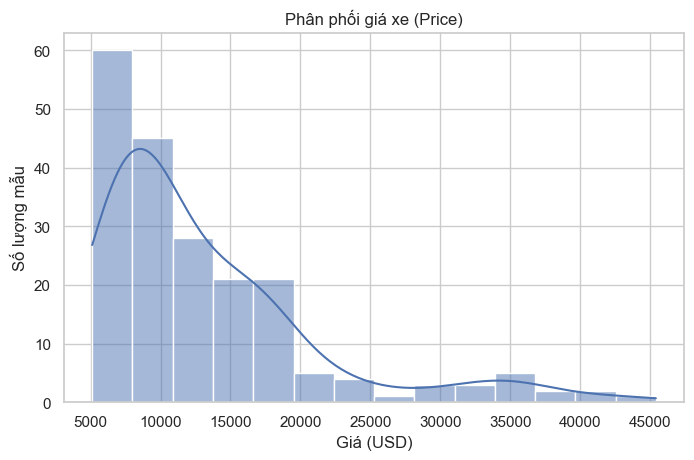

In [20]:
# TODO M2.1: histogram/KDE của price
plt.figure()
sns.histplot(data=df_clean, x='price', kde=True)
plt.title("Phân phối giá xe (Price)")
plt.xlabel("Giá (USD)")
plt.ylabel("Số lượng mẫu")
plt.show()

**Nhận xét:** Giá xe có phân phối lệch phải (right-skewed). Phần lớn các mẫu xe tập trung ở phân khúc giá rẻ dưới 15,000 USD.

## M2.2 Dataset có cân bằng theo body style không?

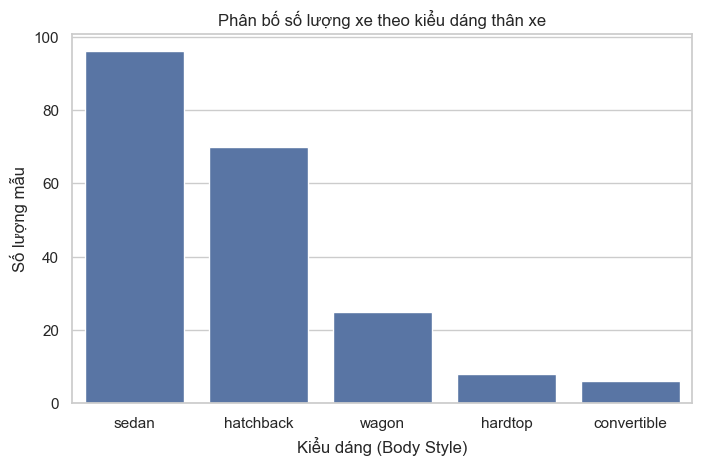

In [21]:
# TODO M2.2: countplot của body_style
plt.figure()
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index)
plt.title("Phân bố số lượng xe theo kiểu dáng thân xe")
plt.xlabel("Kiểu dáng (Body Style)")
plt.ylabel("Số lượng mẫu")
plt.show()

**Nhận xét:** Không, dataset bị mất cân bằng theo body style. Kiểu dán sedan và hatchback chiếm phần lớn trong khi các kiểu dáng khác lại ít xuất hiện hơn trong dataset

## M2.3 Price khác nhau theo body style ra sao?

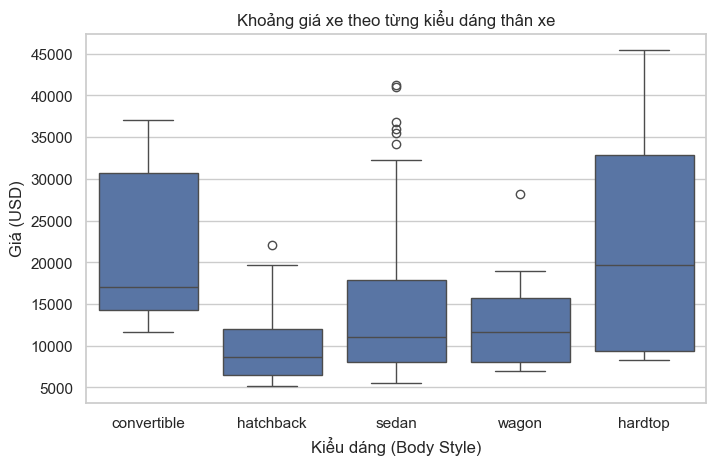

In [22]:
# TODO M2.3: boxplot price theo body_style
plt.figure()
sns.boxplot(data=df_clean, x='body_style', y='price')
plt.title("Khoảng giá xe theo từng kiểu dáng thân xe")
plt.xlabel("Kiểu dáng (Body Style)")
plt.ylabel("Giá (USD)")
plt.show()

**Nhận xét:** Xe hardtop và convertible có khoảng giá trung bình cao nhất và mức độ phân tán giá rộng. Ngược lại, hatchback thường là các dòng xe thuộc phân khúc giá rẻ bình dân.

## M2.4 Engine size liên quan thế nào tới price?

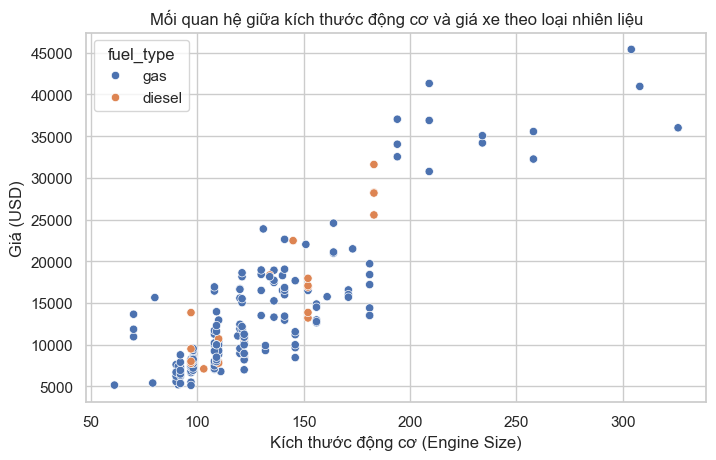

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure()
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type')
plt.title("Mối quan hệ giữa kích thước động cơ và giá xe theo loại nhiên liệu")
plt.xlabel("Kích thước động cơ (Engine Size)")
plt.ylabel("Giá (USD)")
plt.show()

**Nhận xét:** Có độ tương quan thuận cao, nghĩa là động cơ càng lớn thì giá thành càng cao.

## M2.5 Các feature numeric tương quan ra sao?

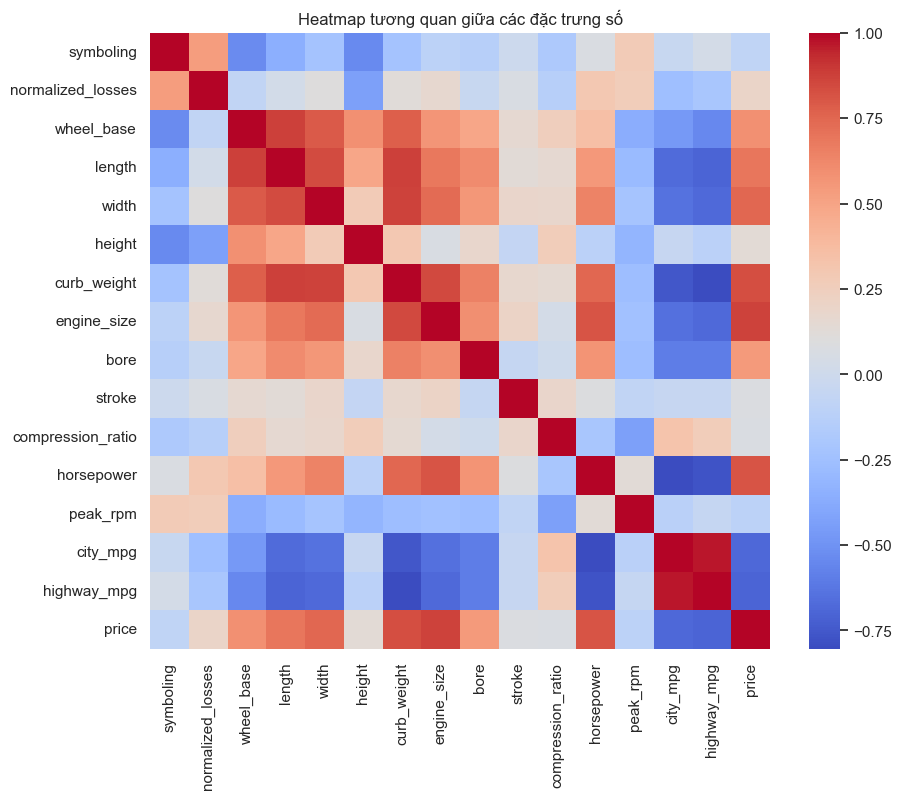

In [24]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[NUMERIC_COLUMNS].corr(), annot=False, cmap='coolwarm')
plt.title("Heatmap tương quan giữa các đặc trưng số")
plt.show()

**Nhận xét:** price tương quan thuận mạnh với các đặc trưng phần cứng (engine_size, horsepower, curb_weight), nhưng tương quan nghịch với chỉ số tiết kiệm nhiên liệu (city_mpg, highway_mpg).

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

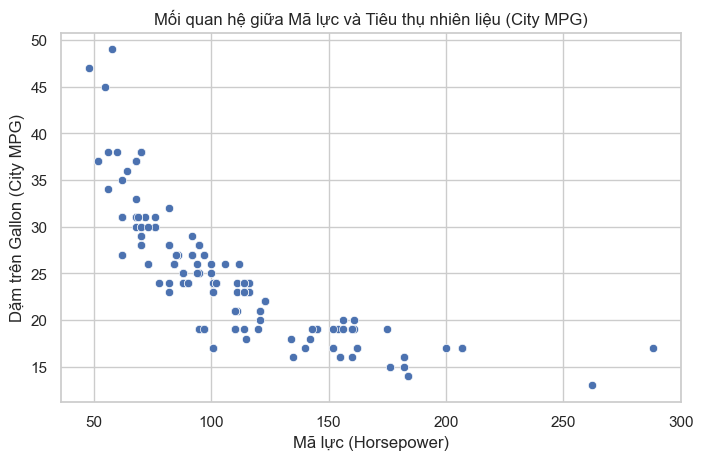

In [25]:
# TODO M2.6: biểu đồ tự chọn
plt.figure()
sns.scatterplot(data=df_clean, x='horsepower', y='city_mpg')
plt.title("Mối quan hệ giữa Mã lực và Tiêu thụ nhiên liệu (City MPG)")
plt.xlabel("Mã lực (Horsepower)")
plt.ylabel("Dặm trên Gallon (City MPG)")
plt.show()

**Nhận xét:** Tồn tại sự tương quan nghịch phi tuyến tính, nghĩa là xe có mã lực càng cao thì chỉ số MPG càng thấp (mức tiết kiệm nhiên liệu thấp hơn).

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Phát hiện chính:

- Giá xe trong tập dữ liệu lệch phải, phần lớn nằm ở phân khúc giá bình dân dưới 15,000 USD.

- Dữ liệu mất cân bằng nặng về body style (sedan và hatchback chiếm phần lớn).

- Tồn tại tương quan thuận rất mạnh giữa giá xe với kích thước động cơ, mã lực và trọng lượng xe.

Hạn chế của dataset:

- Dataset khá nhỏ và mất cân bằng class, dễ gây hiện tượng overfitting nếu train trực tiếp các mô hình phân loại phụ thuộc vào body_style.

- Một số tính năng quan trọng như normalized_losses bị thiếu quá nhiều dữ liệu, gây cản trở trong việc phân tích rủi ro tài chính một cách toàn diện.

1 Ví dụ Correlation không đồng nghĩa với Causation:
- Xe có giá cao thường có trọng lượng lớn (correlation). Tuy nhiên, cố tình làm xe nặng hơn không khiến nó đắt tiền hơn. Nguyên nhân (causation) là do xe hạng sang thường được trang bị động cơ lớn và nhiều tính năng an toàn/giải trí phức tạp, dẫn tới việc trọng lượng tăng lên như một điều hiển nhiên.

Câu hỏi phân tích tiếp theo:
drive-wheels và make  tác động kết hợp như thế nào đến giá thành ở từng phân khúc xe riêng biệt?